In [3]:
!pip install pandas numpy matplotlib seaborn scikit-learn

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics.pairwise import cosine_similarity

print("Libraries imported successfully!")

Libraries imported successfully!


In [11]:
movies = pd.read_csv("data/movies.csv")
ratings = pd.read_csv("data/ratings.csv")

print("Movies dataset:")
display(movies.head())

print("\nRatings dataset:")
display(ratings.head())

Movies dataset:


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy



Ratings dataset:


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [12]:
print("Movies:", movies.shape)
print("Ratings:", ratings.shape)

Movies: (9742, 3)
Ratings: (100836, 4)


In [13]:
print("Movie columns:")
print(movies.columns.tolist())

print("\nRating columns:")
print(ratings.columns.tolist())

Movie columns:
['movieId', 'title', 'genres']

Rating columns:
['userId', 'movieId', 'rating', 'timestamp']


In [14]:
print("Missing values in movies:")
print(movies.isnull().sum())

print("\nMissing values in ratings:")
print(ratings.isnull().sum())

Missing values in movies:
movieId    0
title      0
genres     0
dtype: int64

Missing values in ratings:
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64


In [15]:
print("Duplicate movies:", movies.duplicated().sum())
print("Duplicate ratings:", ratings.duplicated().sum())

Duplicate movies: 0
Duplicate ratings: 0


In [16]:
print(ratings["rating"].describe())

count    100836.000000
mean          3.501557
std           1.042529
min           0.500000
25%           3.000000
50%           3.500000
75%           4.000000
max           5.000000
Name: rating, dtype: float64


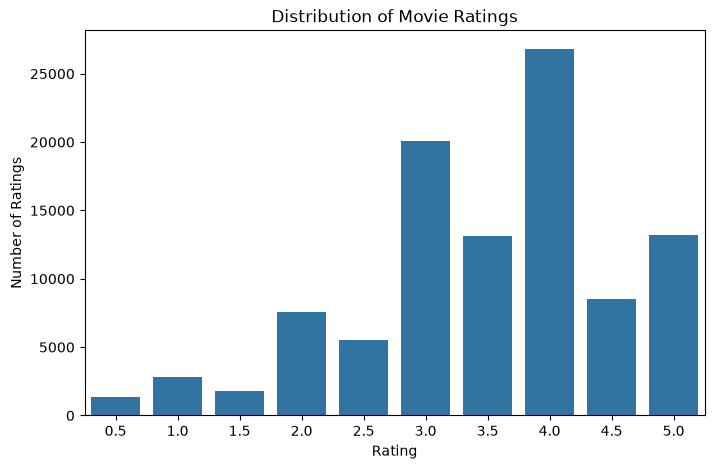

In [17]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=ratings,
    x="rating"
)

plt.title("Distribution of Movie Ratings")
plt.xlabel("Rating")
plt.ylabel("Number of Ratings")

plt.show()

In [18]:
movie_rating_counts = (
    ratings.groupby("movieId")
    .size()
    .reset_index(name="rating_count")
)

movie_rating_counts.head()

,movieId,rating_count
0,1,215
1,2,110
2,3,52
3,4,7
4,5,49


In [19]:
popular_movies = movie_rating_counts.merge(
    movies,
    on="movieId"
)

popular_movies = popular_movies.sort_values(
    "rating_count",
    ascending=False
)

popular_movies.head(10)

,movieId,rating_count,title,genres
314,356,329,Forrest Gump (1994),Comedy|Drama|Romance|War
277,318,317,"Shawshank Redemption, The (1994)",Crime|Drama
257,296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
510,593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
1938,2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
224,260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
418,480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
97,110,237,Braveheart (1995),Action|Drama|War
507,589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi
461,527,220,Schindler's List (1993),Drama|War


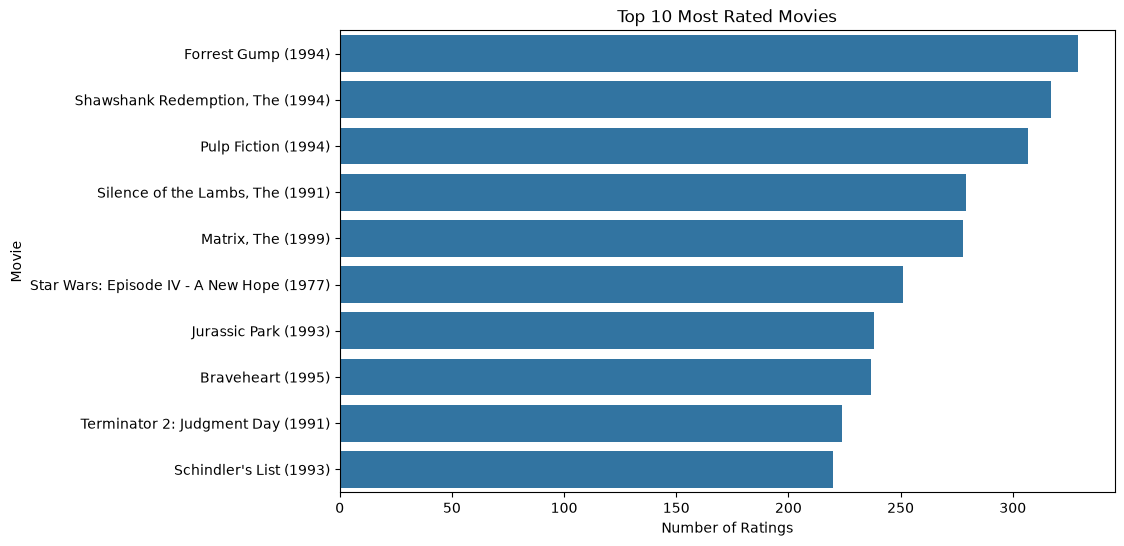

In [20]:
top_movies = popular_movies.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_movies,
    x="rating_count",
    y="title"
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.show()

In [21]:
user_movie_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

user_movie_matrix.head()

movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [22]:
movie_user_matrix = user_movie_matrix.T

movie_user_matrix.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,NaN,NaN,4.0,NaN,4.5,NaN,NaN,NaN,...,4.0,NaN,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,NaN,NaN,NaN,NaN,NaN,4.0,NaN,4.0,NaN,NaN,...,NaN,4.0,NaN,5.0,3.5,NaN,NaN,2.0,NaN,NaN
3,4.0,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,NaN,NaN,NaN,NaN,NaN,5.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,3.0,NaN,NaN,NaN,NaN,NaN,NaN


In [23]:
movie_user_matrix_filled = movie_user_matrix.fillna(0)

movie_user_matrix_filled.head()

userId,1,2,3,4,5,6,7,8,9,10,...,601,602,603,604,605,606,607,608,609,610
movieId,,,,,,,,,,,,,,,,,,,,,
1,4.0,0.0,0.0,0.0,4.0,0.0,4.5,0.0,0.0,0.0,...,4.0,0.0,4.0,3.0,4.0,2.5,4.0,2.5,3.0,5.0
2,0.0,0.0,0.0,0.0,0.0,4.0,0.0,4.0,0.0,0.0,...,0.0,4.0,0.0,5.0,3.5,0.0,0.0,2.0,0.0,0.0
3,4.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,5.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,3.0,0.0,0.0,0.0,0.0,0.0,0.0


In [24]:
similarity_matrix = cosine_similarity(
    movie_user_matrix_filled
)

print(similarity_matrix.shape)

(9724, 9724)


In [42]:
def recommend_movies(movie_title, n=10):

    # Find the movie
    movie_data = movies[
        movies["title"].str.lower() == movie_title.lower()
    ]

    if movie_data.empty:
        print("Movie not found.")
        return

    # Get movie ID
    movie_id = movie_data.iloc[0]["movieId"]

    # Find the movie's position in the similarity matrix
    movie_position = movie_user_matrix.index.get_loc(movie_id)

    # Get similarity scores for this movie
    similarity_scores = similarity_matrix[movie_position]

    # Get positions of most similar movies
    similar_positions = similarity_scores.argsort()[::-1][1:n+1]

    # Get movie IDs
    similar_movie_ids = movie_user_matrix.index[
        similar_positions
    ]

    # Get similarity scores
    scores = similarity_scores[similar_positions]

    # Get movie information
    recommendations = movies[
        movies["movieId"].isin(similar_movie_ids)
    ].copy()

    # Add similarity scores
    score_df = pd.DataFrame({
        "movieId": similar_movie_ids,
        "similarity_score": scores
    })

    recommendations = recommendations.merge(
        score_df,
        on="movieId"
    )

    # Sort by similarity
    recommendations = recommendations.sort_values(
        "similarity_score",
        ascending=False
    )

    return recommendations[
        ["title", "genres", "similarity_score"]
    ]

In [26]:
recommend_movies("Toy Story (1995)")

,title,genres,similarity_score
9,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.572601
3,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.565637
5,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller,0.564262
0,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.557388
1,Forrest Gump (1994),Comedy|Drama|Romance|War,0.547096
2,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,0.541145
6,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.541089
4,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller,0.538913
7,Groundhog Day (1993),Comedy|Fantasy|Romance,0.534169
8,Back to the Future (1985),Adventure|Comedy|Sci-Fi,0.530381


In [27]:
recommend_movies("Jumanji (1995)")

,title,genres,similarity_score
2,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,0.588438
5,Mrs. Doubtfire (1993),Comedy|Drama,0.549818
3,"Mask, The (1994)",Action|Comedy|Crime|Fantasy,0.544981
4,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.538046
7,Home Alone (1990),Children|Comedy,0.524876
6,"Nightmare Before Christmas, The (1993)",Animation|Children|Fantasy|Musical,0.518161
8,Aladdin (1992),Adventure|Animation|Children|Comedy|Musical,0.515620
9,Beauty and the Beast (1991),Animation|Children|Fantasy|Musical|Romance|IMAX,0.507458
0,Ace Ventura: When Nature Calls (1995),Comedy,0.497560
1,"Santa Clause, The (1994)",Comedy|Drama|Fantasy,0.497368


In [28]:
recommend_movies("The Matrix (1999)")

,Message
0,Movie not found.


In [29]:
recommend_movies("Toy Story (1995)")

,title,genres,similarity_score
9,Toy Story 2 (1999),Adventure|Animation|Children|Comedy|Fantasy,0.572601
3,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.565637
5,Independence Day (a.k.a. ID4) (1996),Action|Adventure|Sci-Fi|Thriller,0.564262
0,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi,0.557388
1,Forrest Gump (1994),Comedy|Drama|Romance|War,0.547096
2,"Lion King, The (1994)",Adventure|Animation|Children|Drama|Musical|IMAX,0.541145
6,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi,0.541089
4,Mission: Impossible (1996),Action|Adventure|Mystery|Thriller,0.538913
7,Groundhog Day (1993),Comedy|Fantasy|Romance,0.534169
8,Back to the Future (1985),Adventure|Comedy|Sci-Fi,0.530381


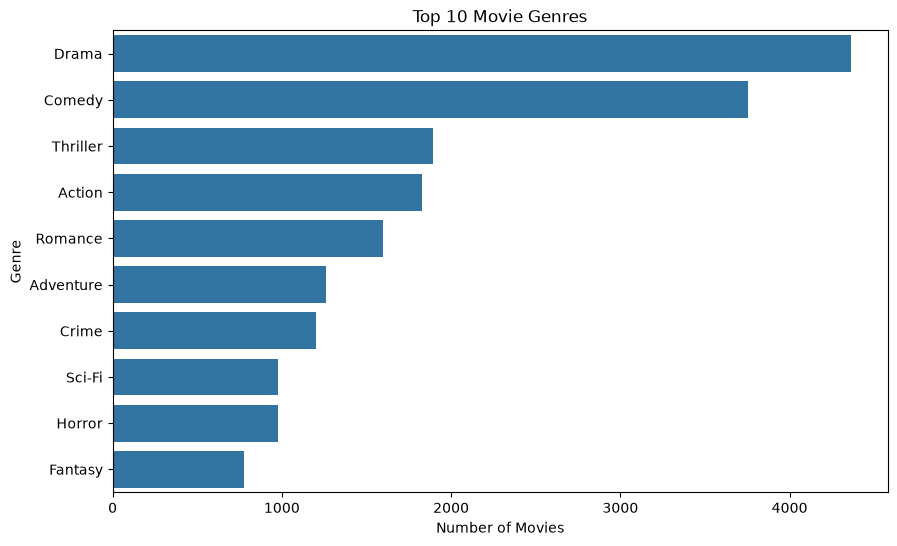

In [30]:
genre_counts = (
    movies["genres"]
    .str.split("|")
    .explode()
    .value_counts()
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.head(10).values,
    y=genre_counts.head(10).index
)

plt.title("Top 10 Movie Genres")
plt.xlabel("Number of Movies")
plt.ylabel("Genre")

plt.show()

In [31]:
recommendations = recommend_movies(
    "Toy Story (1995)",
    10
)

recommendations.to_csv(
    "outputs/recommendations.csv",
    index=False
)

print("Recommendations saved successfully!")

Recommendations saved successfully!


In [32]:
popular_movies = movie_rating_counts.merge(
    movies,
    on="movieId"
)

popular_movies = popular_movies.sort_values(
    "rating_count",
    ascending=False
)

popular_movies.head(10)

,movieId,rating_count,title,genres
314,356,329,Forrest Gump (1994),Comedy|Drama|Romance|War
277,318,317,"Shawshank Redemption, The (1994)",Crime|Drama
257,296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
510,593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
1938,2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
224,260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
418,480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
97,110,237,Braveheart (1995),Action|Drama|War
507,589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi
461,527,220,Schindler's List (1993),Drama|War


In [33]:
popular_movies = movie_rating_counts.merge(
    movies,
    on="movieId"
)

popular_movies = popular_movies.sort_values(
    "rating_count",
    ascending=False
)

popular_movies.head(10)

,movieId,rating_count,title,genres
314,356,329,Forrest Gump (1994),Comedy|Drama|Romance|War
277,318,317,"Shawshank Redemption, The (1994)",Crime|Drama
257,296,307,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller
510,593,279,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller
1938,2571,278,"Matrix, The (1999)",Action|Sci-Fi|Thriller
224,260,251,Star Wars: Episode IV - A New Hope (1977),Action|Adventure|Sci-Fi
418,480,238,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller
97,110,237,Braveheart (1995),Action|Drama|War
507,589,224,Terminator 2: Judgment Day (1991),Action|Sci-Fi
461,527,220,Schindler's List (1993),Drama|War


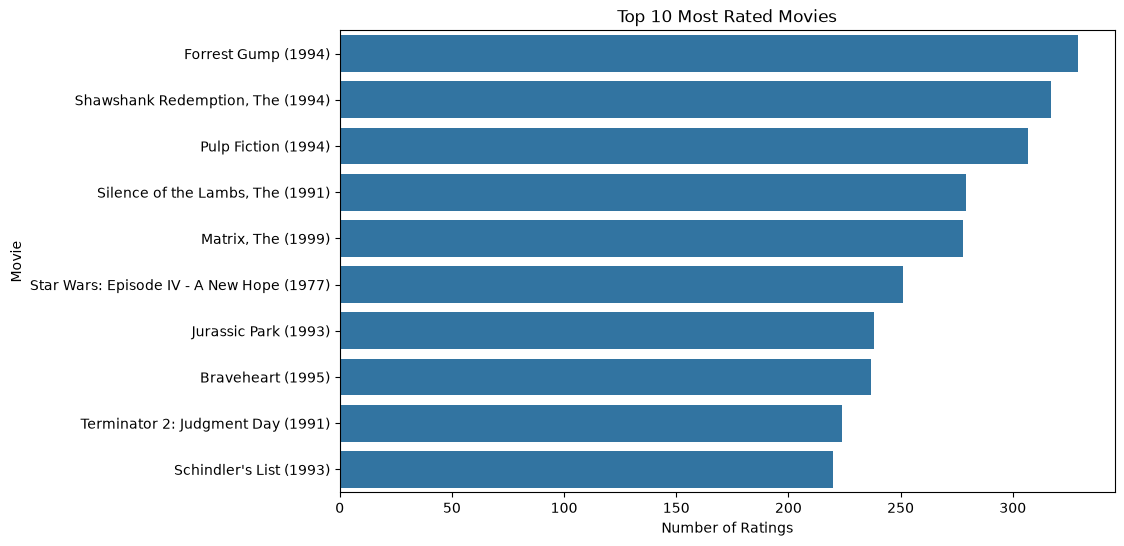

In [34]:
top_movies = popular_movies.head(10)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=top_movies,
    x="rating_count",
    y="title"
)

plt.title("Top 10 Most Rated Movies")
plt.xlabel("Number of Ratings")
plt.ylabel("Movie")

plt.show()

In [35]:
user_movie_matrix = ratings.pivot_table(
    index="userId",
    columns="movieId",
    values="rating"
)

print("User-Movie Matrix Shape:", user_movie_matrix.shape)

display(user_movie_matrix.head())

User-Movie Matrix Shape: (610, 9724)


movieId,1,2,3,4,5,6,7,8,9,10,...,193565,193567,193571,193573,193579,193581,193583,193585,193587,193609
userId,,,,,,,,,,,,,,,,,,,,,
1,4.0,NaN,4.0,NaN,NaN,4.0,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
movie_user_matrix = user_movie_matrix.T

movie_user_matrix_filled = movie_user_matrix.fillna(0)


In [40]:
similarity_matrix = cosine_similarity(
    movie_user_matrix_filled
)

In [43]:
recommend_movies("Forrest Gump (1994)")

,title,genres,similarity_score
3,"Shawshank Redemption, The (1994)",Crime|Drama,0.712993
4,Jurassic Park (1993),Action|Adventure|Sci-Fi|Thriller,0.688259
2,Pulp Fiction (1994),Comedy|Crime|Drama|Thriller,0.685544
0,Braveheart (1995),Action|Drama|War,0.643090
8,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,0.639463
1,Apollo 13 (1995),Adventure|Drama|IMAX,0.627559
9,"Matrix, The (1999)",Action|Sci-Fi|Thriller,0.609935
5,Mrs. Doubtfire (1993),Comedy|Drama,0.607983
6,Schindler's List (1993),Drama|War,0.602072
7,Terminator 2: Judgment Day (1991),Action|Sci-Fi,0.600886


In [44]:
recommend_movies("The Matrix (1999)")

Movie not found.


In [45]:
recommend_movies("Pulp Fiction (1994)")

,title,genres,similarity_score
6,"Silence of the Lambs, The (1991)",Crime|Horror|Thriller,0.709382
3,"Shawshank Redemption, The (1994)",Crime|Drama,0.702366
0,Seven (a.k.a. Se7en) (1995),Mystery|Thriller,0.697654
4,Forrest Gump (1994),Comedy|Drama|Romance|War,0.685544
1,"Usual Suspects, The (1995)",Crime|Mystery|Thriller,0.672616
2,Braveheart (1995),Action|Drama|War,0.627621
9,Fight Club (1999),Action|Crime|Drama|Thriller,0.623220
7,Fargo (1996),Comedy|Crime|Drama|Thriller,0.610349
5,Terminator 2: Judgment Day (1991),Action|Sci-Fi,0.610284
8,Reservoir Dogs (1992),Crime|Mystery|Thriller,0.603955


In [46]:
recommend_movies("XYZ Movie 123")

Movie not found.


In [47]:
!pip install streamlit

  Using cached blinker-1.9.0-py3-none-any.whl.metadata (1.6 kB)
  Using cached click-8.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached protobuf-7.35.1-cp310-abi3-win_amd64.whl.metadata (595 bytes)
  Using cached tenacity-9.1.4-py3-none-any.whl.metadata (1.2 kB)
  Using cached starlette-1.3.1-py3-none-any.whl.metadata (6.4 kB)
  Using cached python_multipart-0.0.32-py3-none-any.whl.metadata (2.1 kB)
  Using cached websockets-16.1.1-cp312-cp312-win_amd64.whl.metadata (7.0 kB)
  Using cached itsdangerous-2.2.0-py3-none-any.whl.metadata (1.9 kB)
   ---------------------------------------- 0.0/10.5 MB ? eta -:--:--
   --- ------------------------------------ 1.0/10.5 MB 5.6 MB/s eta 0:00:02
   ------- -------------------------------- 2.1/10.5 MB 5.6 MB/s eta 0:00:02
   ------------- -------------------------- 3.7/10.5 MB 5.9 MB/s eta 0:00:02
   ------------------ --------------------- 5.0/10.5 MB 6.2 MB/s eta 0:00:01
   ---------------------- ----------------- 6.0/10.5 MB 5.9 MB/s eta